# 1. Import Libraries

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.naive_bayes import GaussianNB


import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.utils.class_weight import compute_class_weight
from matplotlib.colors import ListedColormap
import xgboost as xgb
from sklearn.metrics import precision_score, recall_score, f1_score




# 2. Load & Merge Raw CSVs






In [ ]:
# Load individual daily CSV files from the CSE-CIC-IDS2018 dataset
df_01 = pd.read_csv("CSE-CIC-IDS2018/02-14-2018.csv")
df_02 = pd.read_csv("CSE-CIC-IDS2018/02-15-2018.csv")
df_03 = pd.read_csv("CSE-CIC-IDS2018/02-22-2018.csv")
df_04 = pd.read_csv("CSE-CIC-IDS2018/03-02-2018.csv")

In [ ]:
# Combine all daily datasets into one unified DataFrame
df = pd.concat([df_01, df_02, df_03, df_04], ignore_index=True)

# 3. Preprocess Labels for Multiclass Classification

In [ ]:
# Group granular attack types into broader threat categories
label_map = {
    'Benign': 'Benign',
    'FTP-BruteForce': 'Credential-based',
    'SSH-Bruteforce': 'Credential-based',
    'Brute Force -Web': 'Credential-based',
    'Brute Force -XSS': 'Application-level',
    'DoS attacks-GoldenEye': 'Volumetric',
    'DoS attacks-Slowloris': 'Volumetric',
    'SQL Injection': 'Application-level',
    'Bot': 'Behavioral'
}
# Map and encode string labels to numeric class IDs
df['MappedLabel'] = df['Label'].map(label_map)
df['label'] = df['MappedLabel'].apply(lambda x: {'Benign': 0, 'Credential-based': 1, 'Application-level': 2, 'Volumetric': 3, 'Behavioral': 4}[x])
# View class distribution (helps understand imbalance)
df['label'].value_counts()

label
0    3474300
1     381198
4     286191
3      52498
2        113
Name: count, dtype: int64

# 4. Feature Selection and Cleanup

In [ ]:
# Separate target and feature set; exclude metadata and label columns
y = df['label']
X = df.loc[:, ~df.columns.isin(['Label', 'MappedLabel', 'label', 'Timestamp', 'Protocol', 'Dst Port'])] #dropping irrelevant columns and labels

# 5. Handle Missing and Infinite Values

In [ ]:
# Find columns that contain NaNs or infinite values — these need fixing
bad_cols = X.columns[X.isnull().any() | np.isinf(X).any()]
print(bad_cols.tolist())

['Flow Byts/s', 'Flow Pkts/s']


In [ ]:
# Replace infinite values with NaNs
X_clean = X.copy()
X_clean.replace([np.inf, -np.inf], np.nan, inplace=True)
# Fill NaNs in selected rate-based features using median 
for col in ['Flow Byts/s', 'Flow Pkts/s']:
    median_val = X_clean[col].median()
    X_clean[col].fillna(median_val, inplace=True)

C:\Users\T\AppData\Local\Temp\ipykernel_22816\2261705546.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_clean[col].fillna(median_val, inplace=True)
C:\Users\T\AppData\Local\Temp\ipykernel_22816\2261705546.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when 

# 6. Normalise Feature Values

In [ ]:
# Scale features to zero mean and unit variance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

# 7. Train-Test Split with Stratification

In [ ]:
# Split data with stratification to preserve label distribution across sets
X_train, X_test, y_train, y_test= train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)


# 8. Class Weight Calculation

In [ ]:
# Address imbalance by computing class weights for each category
classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))

# 9. Train Neural Network

In [ ]:
# Early stopping prevents overfitting and saves best weight
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Build a basic feedforward classifier
model = Sequential([
    Dense(64, input_dim=X_train.shape[1], activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(len(classes), activation='softmax')
])

# Compile model with sparse labels and accuracy tracking
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train model with validation monitoring and early stopping
history = model.fit(X_train, y_train, epochs=10, batch_size=128, validation_data=(X_test, y_test),callbacks=[early_stop])


c:\Users\T\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
26215/26215 ━━━━━━━━━━━━━━━━━━━━ 52s 2ms/step - accuracy: 0.9835 - loss: 0.0527 - val_accuracy: 0.9956 - val_loss: 0.0159
Epoch 2/10
26215/26215 ━━━━━━━━━━━━━━━━━━━━ 49s 2ms/step - accuracy: 0.9952 - loss: 0.0208 - val_accuracy: 0.9960 - val_loss: 0.0118
Epoch 3/10
26215/26215 ━━━━━━━━━━━━━━━━━━━━ 76s 3ms/step - accuracy: 0.9955 - loss: 0.0152 - val_accuracy: 0.9960 - val_loss: 0.0121
Epoch 4/10
26215/26215 ━━━━━━━━━━━━━━━━━━━━ 71s 3ms/step - accuracy: 0.9956 - loss: 0.0153 - val_accuracy: 0.9960 - val_loss: 0.0116
Epoch 5/10
26215/26215 ━━━━━━━━━━━━━━━━━━━━ 124s 5ms/step - accuracy: 0.9956 - loss: 0.0138 - val_accuracy: 0.9960 - val_loss: 0.0117
Epoch 6/10
26215/26215 ━━━━━━━━━━━━━━━━━━━━ 45s 2ms/step - accuracy: 0.9956 - loss: 0.0177 - val_accuracy: 0.9961 - val_loss: 0.0123
Epoch 7/10
26215/26215 ━━━━━━━━━━━━━━━━━━━━ 43s 2ms/step - accuracy: 0.9955 - loss: 0.0190 - val_accuracy: 0.9960 - val_loss: 0.0115
Epoch 8/10
26215/26215 ━━━━━━━━━━━━━━━━━━━━ 44s 2ms/step - accuracy:

# 10. Deep Learning Evaluation

In [ ]:
# Predict probabilities and convert to class labels
y_pred_dl_raw = model.predict(X_test) 
y_pred_dl = np.argmax(y_pred_dl_raw, axis=1) 

# Print evaluation metrics
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dl))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dl, digits=4))

26215/26215 ━━━━━━━━━━━━━━━━━━━━ 18s 696us/step
Confusion Matrix:
[[694674      5      0     37    144]
 [    27  76206      0      1      6]
 [    21      0      0      0      2]
 [    32      0      0  10467      0]
 [  3049      0      0      0  54189]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9955    0.9997    0.9976    694860
           1     0.9999    0.9996    0.9997     76240
           2     0.0000    0.0000    0.0000        23
           3     0.9964    0.9970    0.9967     10499
           4     0.9972    0.9467    0.9713     57238

    accuracy                         0.9960    838860
   macro avg     0.7978    0.7886    0.7931    838860
weighted avg     0.9960    0.9960    0.9960    838860



c:\Users\T\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\T\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\T\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

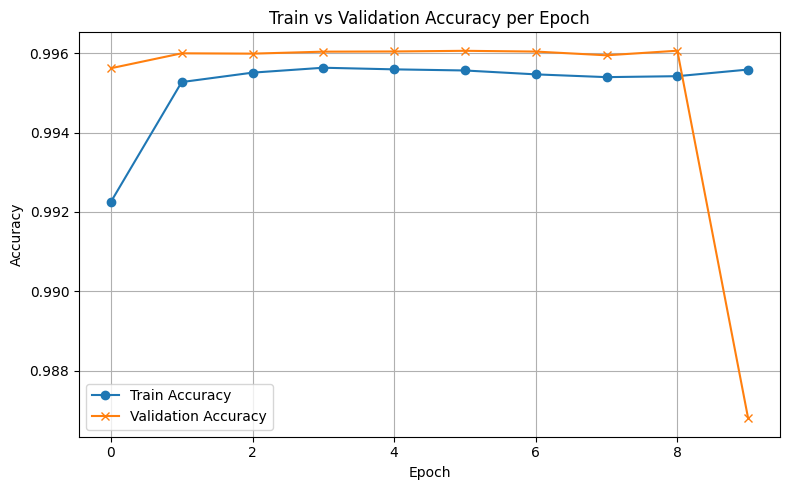

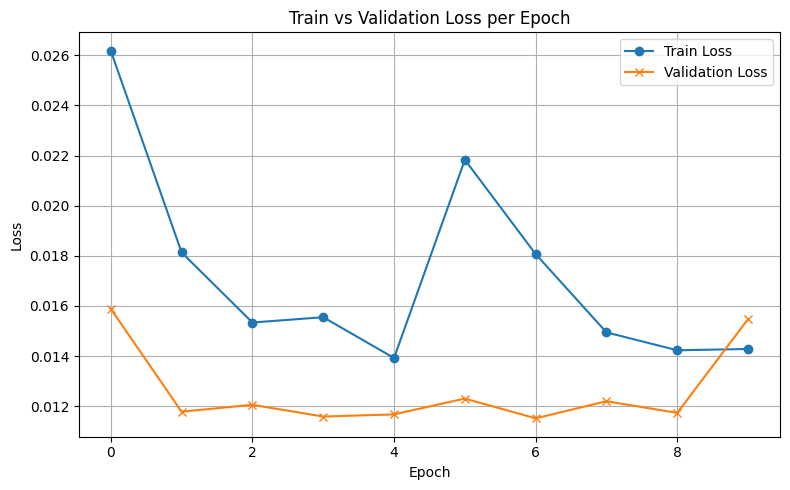

In [ ]:
# Accuracy vs Epochs
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='x')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Train vs Validation Accuracy per Epoch')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Loss vs Epochs
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='x')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train vs Validation Loss per Epoch')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

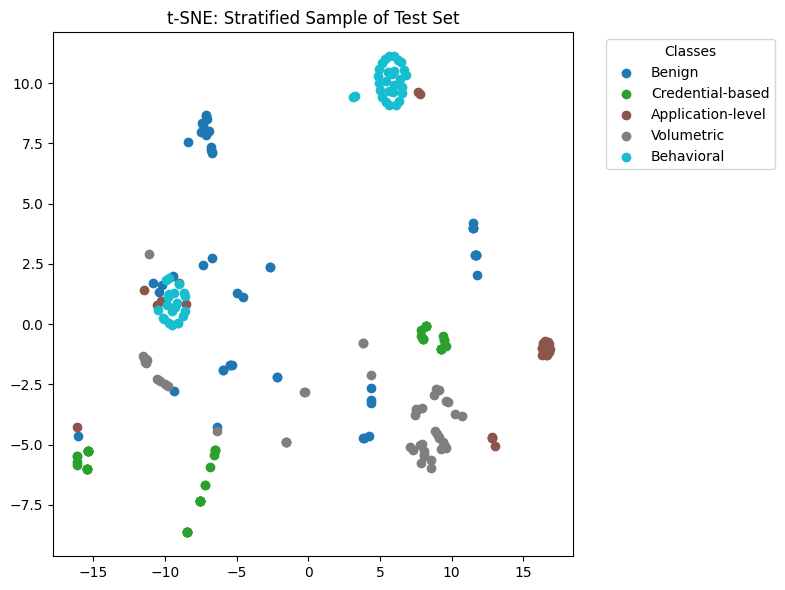

In [15]:
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

samples_per_class = 50

unique_labels = np.unique(y_test)
indices = []

for label in unique_labels:
    label_indices = np.where(y_test == label)[0]
    sampled = np.random.choice(label_indices, size=min(samples_per_class, len(label_indices)), replace=False)
    indices.extend(sampled)

X_sample = X_test[indices]
y_sample = y_test.iloc[indices]

X_scaled = StandardScaler().fit_transform(X_sample)

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

class_names = ['Benign', 'Credential-based', 'Application-level', 'Volumetric', 'Behavioral']
unique_classes = np.unique(y_sample)
colors = plt.cm.tab10(np.linspace(0, 1, len(class_names)))

plt.figure(figsize=(8, 6))
for cls in unique_classes:
    ix = y_sample == cls
    plt.scatter(X_tsne[ix, 0], X_tsne[ix, 1], label=class_names[cls], c=[colors[cls]])

plt.legend(title="Classes", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("t-SNE: Stratified Sample of Test Set")
plt.tight_layout()
plt.show()

# 11. Sample Weights For XGBoost

In [ ]:
# Manually generate sample weights for class balancing in XGBoost
classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
weight_map = dict(zip(classes, weights))
sample_weights = np.array([weight_map[label] for label in y_train])



# 12. Train and Evaluate XGBoost

In [ ]:
# Build multiclass XGBoost model
xgb_model = xgb.XGBClassifier(
    objective='multi:softprob', 
    eval_metric='mlogloss',     
    use_label_encoder=False,
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)
# Fit with sample weighting
xgb_model.fit(X_train, y_train, sample_weight=sample_weights)

y_pred_xgb = xgb_model.predict(X_test)

# Evaluate
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb))

c:\Users\T\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [21:42:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    694860
           1       1.00      1.00      1.00     76240
           2       0.45      0.91      0.60        23
           3       0.96      1.00      0.98     10499
           4       0.99      1.00      1.00     57238

    accuracy                           1.00    838860
   macro avg       0.88      0.98      0.92    838860
weighted avg       1.00      1.00      1.00    838860



# 13. Side-By-Side Metric Evaluation

c:\Users\T\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


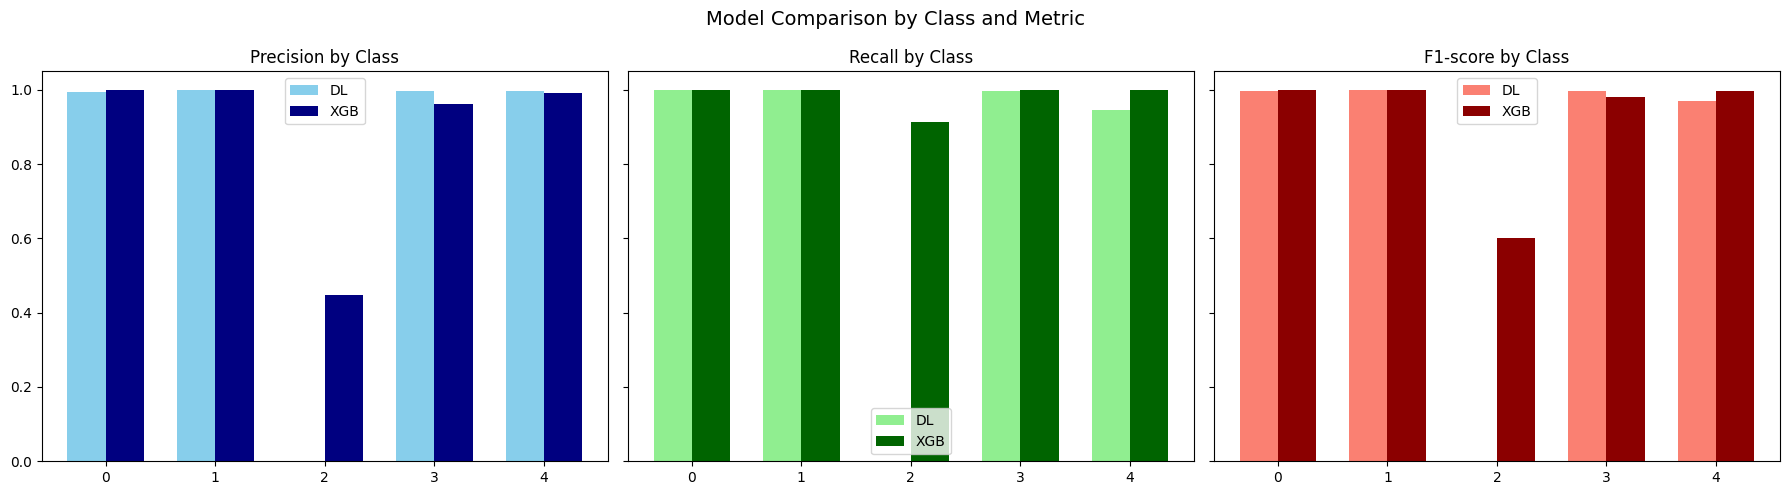

In [ ]:
# Set up per-class evaluation
class_labels = [0, 1, 2, 3, 4]
x = np.arange(len(class_labels))

# Compute metrics for DL
precision_dl = precision_score(y_test, y_pred_dl, labels=class_labels, average=None)
recall_dl    = recall_score(y_test, y_pred_dl, labels=class_labels, average=None)
f1_dl        = f1_score(y_test, y_pred_dl, labels=class_labels, average=None)

# Compute metrics for XGB
precision_xgb = precision_score(y_test, y_pred_xgb, labels=class_labels, average=None)
recall_xgb    = recall_score(y_test, y_pred_xgb, labels=class_labels, average=None)
f1_xgb        = f1_score(y_test, y_pred_xgb, labels=class_labels, average=None)


# Plot precision, recall, F1
width = 0.35
fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# Precision
axs[0].bar(x - width/2, precision_dl, width, label='DL', color='skyblue')
axs[0].bar(x + width/2, precision_xgb, width, label='XGB', color='navy')
axs[0].set_title('Precision by Class')
axs[0].set_xticks(x)
axs[0].set_xticklabels(class_labels)
axs[0].legend()

axs[1].bar(x - width/2, recall_dl, width, label='DL', color='lightgreen')
axs[1].bar(x + width/2, recall_xgb, width, label='XGB', color='darkgreen')
axs[1].set_title('Recall by Class')
axs[1].set_xticks(x)
axs[1].set_xticklabels(class_labels)
axs[1].legend()

axs[2].bar(x - width/2, f1_dl, width, label='DL', color='salmon')
axs[2].bar(x + width/2, f1_xgb, width, label='XGB', color='darkred')
axs[2].set_title('F1-score by Class')
axs[2].set_xticks(x)
axs[2].set_xticklabels(class_labels)
axs[2].legend()

fig.suptitle('Model Comparison by Class and Metric', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Naive Bayes fails on large dataset due to memory-intensive sample_weight handling.
# Internally expands dense arrays; not scalable for 2M+ samples. Skip NB for large-scale runs.
nb_model = GaussianNB()
nb_model.fit(X_train, y_train, sample_weight=sample_weights)

y_pred_nb = nb_model.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb, digits=4))


MemoryError: Unable to allocate 1.90 GiB for an array with shape (3355440, 76) and data type float64